In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import itertools
import math
import copy
import ptitprince as pt



species_color = {'Marmoset': "orange",
 'Human': "green",
 'Rhesus': "blue",
 'Chimpanzee': "red",
 'Capuchin': "brown",
 "Gorilla": "pink"}

#PYTHON_PATH = "/Users/rb4174/Documents/projects/brain_dev_primates/altricial_brain_vocal_learning"
PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


def condition(column,low_percentil,high_percentil):
    result_min = all(a >= b for a, b in zip(column, low_percentil))
    result_max = all(a <= b for a, b in zip(column, high_percentil))

    if result_min and result_max:
        return True
    else:
        return False
         

/var/folders/ys/4vmt6skn47v69q7dptm_7p3m0000gp/T/ipykernel_87533/968452477.py:5: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


In [17]:
df_fits = pd.read_pickle("{0}/data/derivatives_sensitivity_analysis.pkl".format(PYTHON_PATH)) 
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH),index_col=False)
species_list = ["Human","Marmoset","Chimpanzee","Rhesus","Capuchin","Gorilla"]

Human
Marmoset
Chimpanzee
Rhesus
Capuchin
Gorilla


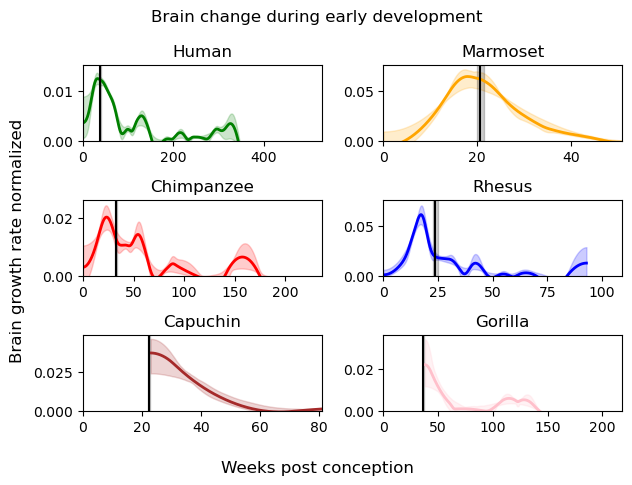

In [29]:
i = 0
derivative_data_species_all = {}
derivative_data_species_all_filtered = {}

derivative_fit = []
fig, ax = plt.subplots(nrows=3, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_fits_specie = df_fits[df_fits.species == species]
        df_event_specie = df_events[df_events.species == species]
        gestation_weeks = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]
        gestation_weeks_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]/7
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]

        x = df_fits_specie["x_dydx"].item()
        y = df_fits_specie["y_dydx"].item()
        low_percentil = df_fits_specie["y_dydx_low_95Percentil"].item()
        high_percentil = df_fits_specie["y_dydx_max_95Percentil"].item()

        #Defining the distribution of rates in the birth interval, USING ALL
        df_derivative_all = {"weeks":x,"low_percentil":low_percentil,"high_percentil":high_percentil}
        for num, item in enumerate(df_fits_specie["all_y"].item()):
            df_derivative_all[num] = df_fits_specie["all_y"].item()[num]/np.max(df_fits_specie["all_y"].item()[num])
            
        df_derivative_all = pd.DataFrame(df_derivative_all)
        derivative_data_species_all[species] = df_derivative_all[(df_derivative_all.weeks >= gestation_weeks - gestation_weeks_sd) & 
                                                        (df_derivative_all.weeks <= gestation_weeks + gestation_weeks_sd)]

        #Plot
        SIGMA = {'Marmoset': 1,'Human': 10,'Rhesus': 10, 'Chimpanzee': 10,"Capuchin": 1, "Gorilla": 1}

        y = gaussian_filter1d(y,sigma = SIGMA[species])
        low_percentil = gaussian_filter1d(low_percentil,sigma = SIGMA[species])
        high_percentil = gaussian_filter1d(high_percentil,sigma = SIGMA[species])

        y = y
        low_percentil = low_percentil
        high_percentil = high_percentil

        col.plot(x,y, '-', color = species_color[species],linewidth = 2)
        col.fill_between(x, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = gestation_weeks, color = "black",linestyle = '-')
        col.axvspan(gestation_weeks - gestation_weeks_sd, gestation_weeks + gestation_weeks_sd, alpha=0.2, color='black')
        
        xlim = late_infancy_ends
        if species == "Marmoset":
            xlim = 50
        col.set_xlim(0,xlim + 1)
        col.set_title(species)
        col.set_ylim(bottom=0)
        i += 1

fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain growth rate normalized')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/SuppM_3A_sensitivityanalysis.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

In [32]:
boxplot_df_all = {"species":[],"possible_values":[]}
for species in df_fits["species"].unique():
    all_values = []
    species_all_dist = derivative_data_species_all[species]
    for column in species_all_dist.columns:
        if column != "weeks":
            all_values.extend(species_all_dist[column])
    boxplot_df_all["possible_values"].extend(all_values)
    boxplot_df_all["species"].extend(len(all_values)*[species])

boxplot_df = pd.DataFrame(boxplot_df_all)



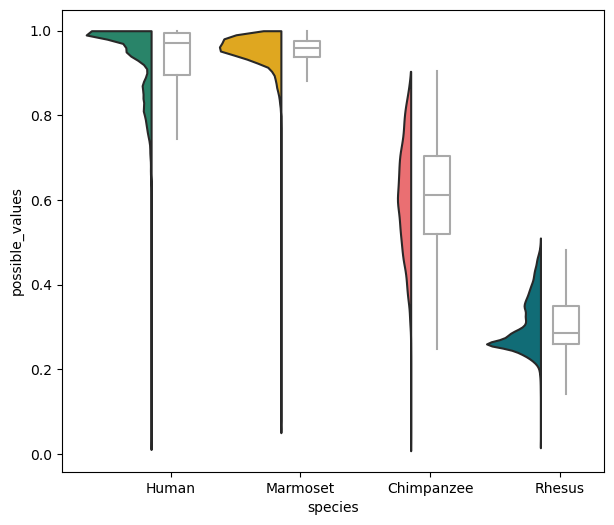

In [34]:
SPECIES = ["Human", "Marmoset","Chimpanzee", "Rhesus"]
COLORS = ["#1A936F","#FFB400","#FF5A5F", "#007A87"]

# Create our own Axes with custom size
fig, ax = plt.subplots(figsize=(7, 6))

# Half-violin plot as above
pt.half_violinplot(
    y="possible_values", x="species", palette=COLORS, 
    order = ["Human","Marmoset","Chimpanzee","Rhesus","Capuchin","Gorilla"],
    inner=None, data=boxplot_df, width=1, ax=ax, cut=0,
)

# Iterate over the species
for i, species in enumerate(SPECIES):
    # Subset the data
    data_subset = boxplot_df[boxplot_df["species"] == species]
    
    # Jitter the values on the vertical axis
    x = i + np.random.uniform(high=0.1, size=len(data_subset))
    
    # Select the values of the horizontal axis
    y = data_subset["possible_values"]
    
    # Add the rain using the scatter method.
    #ax.scatter(x, y, color=COLORS[i], alpha=0.01,s=0.2)

# Generate list of arrays
boxplot_data = [
    boxplot_df[boxplot_df["species"] == species]["possible_values"].values 
    for species in SPECIES
]

# Vertical positions for the boxplots
# Positions are shifted now
SHIFT = 0.05
POSITIONS = [0 + SHIFT, 1 + SHIFT, 2 + SHIFT, 3+ SHIFT]

# The style of the line that represents the median.
medianprops = {"linewidth": 1.5, "color": "#a9a9a9", "solid_capstyle": "butt"}
# The style of the box ... This is also used for the whiskers
boxprops = {"linewidth": 1.5, "color": "#a9a9a9"}

ax.boxplot(
    boxplot_data, 
    vert=True, 
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False, # Do not show the outliers beyond the caps.
    showcaps = False,   # Do not show the caps
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops,
    widths=0.2
)
fig.savefig("{0}/figs/SuppM_3B_sensiti.pdf".format(PYTHON_PATH),dpi = 800)



# percentil bonds of the distributions

In [35]:
percentil = 0.95

for species in derivative_data_species_all.keys():

    try:
        lower_percentile = (1 - percentil) / 2
        upper_percentile = 1 - lower_percentile
        data = boxplot_df[boxplot_df.species == species]["possible_values"]
        confidence_interval = np.percentile(data, [100 * lower_percentile, 100 * upper_percentile])

        mean = np.mean(data)

        print(species)
        print(f"Mean: {mean}")
        print(f"95% Percentil bounds: {confidence_interval}")
        print()
    except:
        print("Error")
        pass    

Human
Mean: 0.9365083695754507
95% Percentil bounds: [0.74806792 0.99991777]

Marmoset
Mean: 0.9531809087057949
95% Percentil bounds: [0.86513913 0.99686647]

Chimpanzee
Mean: 0.6111421895665161
95% Percentil bounds: [0.36703099 0.83954649]

Rhesus
Mean: 0.30510859267795265
95% Percentil bounds: [0.22096999 0.4470024 ]

Error
Error


## ROC curve

<Axes: xlabel='possible_values', ylabel='Count'>

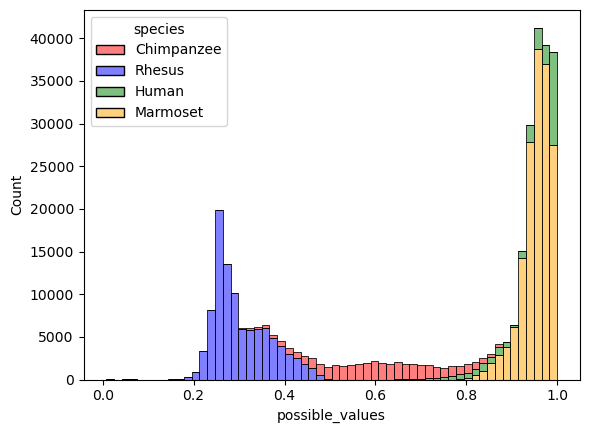

In [36]:
sns.histplot(hue="species", x="possible_values", data=boxplot_df,multiple="stack", alpha = 0.5,
            palette=["red","blue","green","orange"],)

In [37]:
df_all_box = pd.DataFrame(boxplot_df_all)
df_all_box.head()

,species,possible_values
0,Chimpanzee,0.011176
1,Chimpanzee,0.010857
2,Chimpanzee,0.010570
3,Chimpanzee,0.010278
4,Chimpanzee,0.009971


In [38]:
from sklearn.metrics import auc

#ROC calculation
def calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,step=0.01):


    for threshold in np.arange(0, 1 + step, step):
        confusion_matrix["threshold"].append(threshold) #if value >= threshold --> it is altricial (True)
        confusion_matrix["pair_comparison"].append("{0}_{1}".format(pair[0],pair[1]))

        tp = len(altricial_species[altricial_species.possible_values >= threshold])
        confusion_matrix["actually_altricial_predicted_altricial"].append(tp)

        fp = len(precocial_species[precocial_species.possible_values >= threshold])
        confusion_matrix["actually_precocial_predicted_altricial"].append(fp)

        fn = len(altricial_species[altricial_species.possible_values < threshold])
        confusion_matrix["actually_altricial_predicted_precocial"].append(fn)

        tn = len(precocial_species[precocial_species.possible_values < threshold])
        confusion_matrix["actually_precocial_predicted_precocial"].append(tn)

        try:
            confusion_matrix["TPR"].append(tp/(tp + fn))
        except:
            confusion_matrix["TPR"].append(0)
        try:
            confusion_matrix["FPR"].append(fp/(tn + fp))
        except:
            confusion_matrix["FPR"].append(0)

    return confusion_matrix

confusion_matrix_ref = {"actually_altricial_predicted_altricial":[],"actually_precocial_predicted_altricial":[],
                            "actually_altricial_predicted_precocial":[],"actually_precocial_predicted_precocial":[],
                            "pair_comparison":[],"threshold":[],
                            "TPR":[], #true positive rate/recall/sensitivity or true positive/ all positive ("altricials I got right/all altricials")
                            "FPR":[], #false positive rate/ false alarm rate or false positive/ all negative ("precocials I classified as altricial/ all precocials")
                            }

list_of_pairs = [["Marmoset","Rhesus"],["Marmoset","Chimpanzee"],["Human","Rhesus"],["Human","Chimpanzee"],
                ["Human","Marmoset"],["Chimpanzee","Rhesus"]]


confusion_matrix = copy.deepcopy(confusion_matrix_ref)

for pair in list_of_pairs:
    print(pair)
    altricial_species = df_all_box[df_all_box.species == pair[0]]
    precocial_species = df_all_box[df_all_box.species == pair[1]]
    confusion_matrix = calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,0.05)
    
confusion_matrix = pd.DataFrame(confusion_matrix)

['Marmoset', 'Rhesus']
['Marmoset', 'Chimpanzee']
['Human', 'Rhesus']
['Human', 'Chimpanzee']
['Human', 'Marmoset']
['Chimpanzee', 'Rhesus']


Marmoset_Rhesus
Marmoset_Chimpanzee
Human_Rhesus
Human_Chimpanzee
Human_Marmoset
Chimpanzee_Rhesus


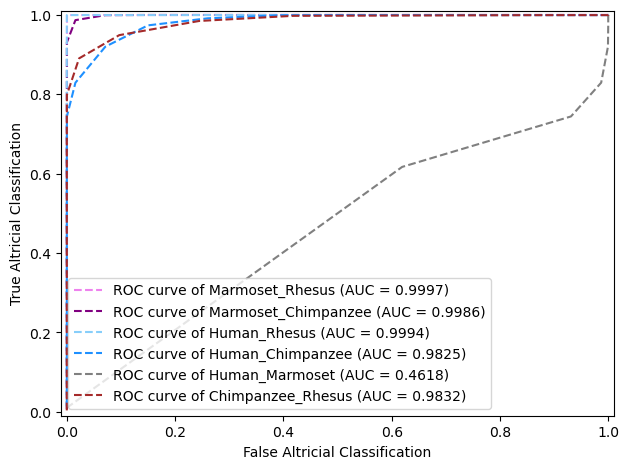

In [39]:
colors = ["violet","purple","lightskyblue","dodgerblue","grey","brown"]

auc_value = 0
for i, pair in enumerate(confusion_matrix["pair_comparison"].unique()):
    print(pair)
    conf_matrix_pair = confusion_matrix[confusion_matrix.pair_comparison == pair]
    fpr = list(conf_matrix_pair["FPR"])
    tpr = list(conf_matrix_pair["TPR"])
    auc_value = auc(fpr,tpr)
    plt.plot(fpr, tpr,"--",color = colors[i],label='ROC curve of {0} (AUC = {1})'.format(pair,np.round(auc_value,4)))

plt.xlim(-0.01,1.01)
plt.ylim(-0.01,1.01)
plt.legend()
plt.xlabel("False Altricial Classification")
plt.ylabel("True Altricial Classification")
plt.tight_layout()

fig.savefig("{0}/figs/SuppM_3C_sensitivityanalysis.pdf".format(PYTHON_PATH),dpi = 800)
